In [24]:
import pandas as pd
import time 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [25]:
data_path = "spotify_long_tracks_2014_2024.csv"

df = pd.read_csv(data_path)

df.head(10)

,ID,Name,Duration (Minutes),Artists
0,026O2YP2wRl9h3Ht9ClZST,Steady Rain in a Forest with Light Background ...,100,Nature Sounds
1,0DXnjJxJBvgMvBjG6Jug7I,Soundarya Lahari,66,Mambalam Sisters
2,6BFn78qFy9bRqKHTMfhnNv,Waves of Abundance & Fullfillment,60,Zen Life Relax
3,1dNwMOMtq3yflXibbqgLku,Mosquito Solution Anti Teen Street Party or Te...,45,Device Sound Effect
4,290gfei8moWWSh8qTVkTT3,Ibiza Sunset Tibetan Singing Bowl Sessions 7 (...,44,Tibetan Singing Bowls
5,23ordmf2KkRfHh9zE9RVyq,佃祭,35,Gontaro Yanagiya
6,47iSvlaCBugj3HrGZDZYcO,Tālā Gaisma (Distant Light),33,"Pēteris Vasks, O/Modernt Chamber Orchestra, Hu..."
7,6fKZZf5Mws3hr31ZAvCOcs,Asmr Tea Massage Roleplay,32,Jessica Cross
8,4J08TVw9zNYeBUtSDIkLP6,Snuggling Up,31,Relaxmydog
9,1IPbXZ2OblHvSUY3Mj58iv,"Keep Driving, I’m Dreaming",30,"Nicole Lizée, Canada's National Arts Centre Or..."


In [26]:
# Getting Shape And Missing Values

df.shape

print("Reading for missing values : ",df.isnull().sum().max())

print("Columns List", df.columns.to_list())


Reading for missing values :  0
Columns List ['ID', 'Name', 'Duration (Minutes)', 'Artists']


In [27]:
# Drop the id we dont needed
dfe = df.copy()

dfe = dfe.drop('ID', axis=1)


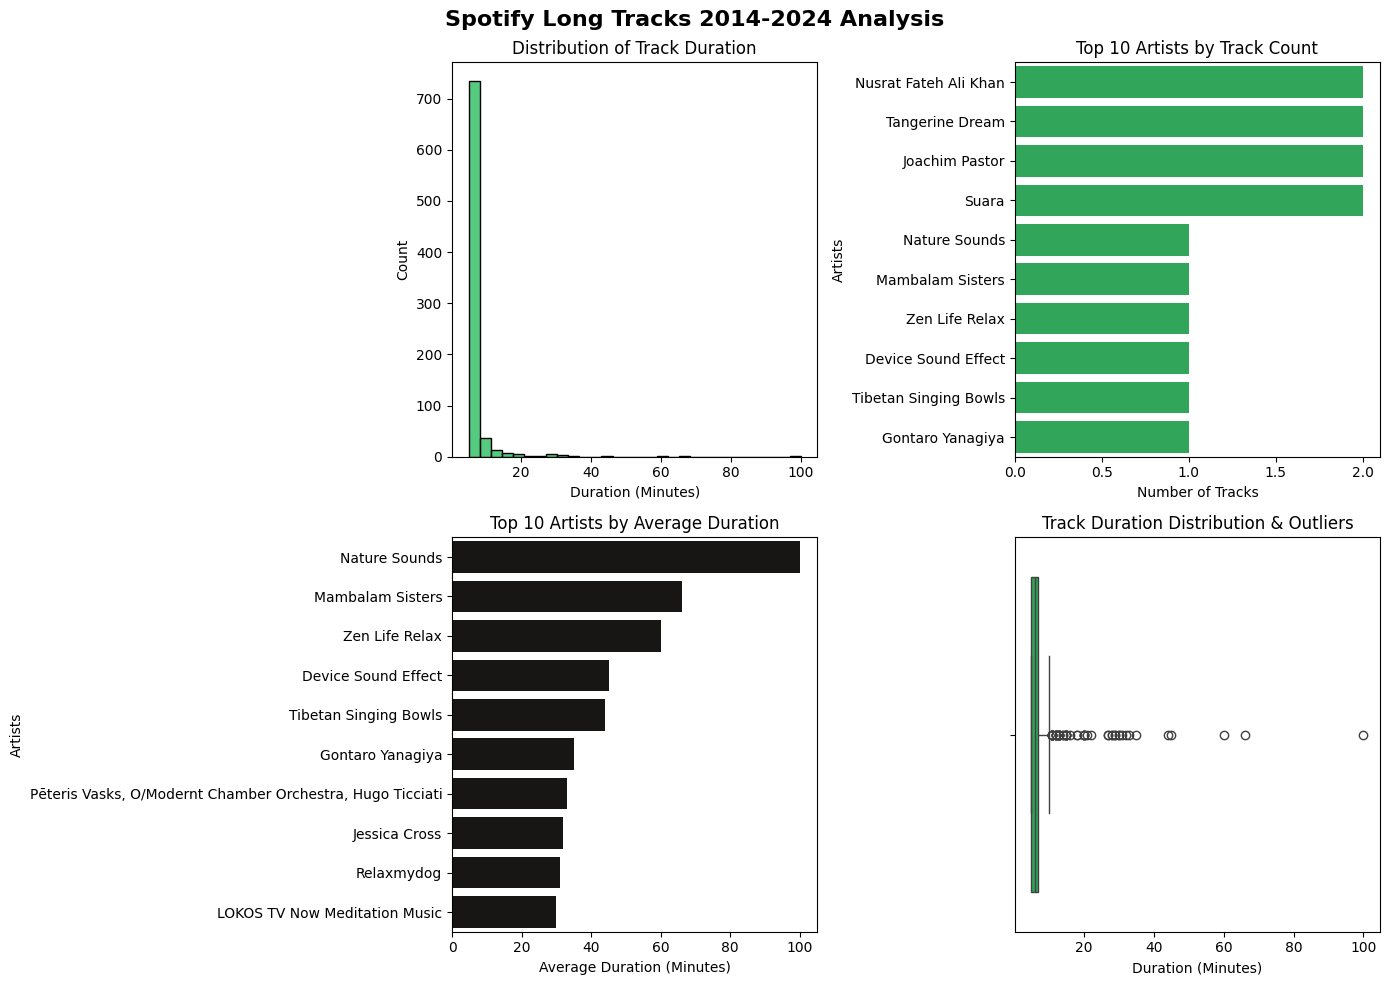

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Spotify Long Tracks 2014-2024 Analysis', fontsize=16, fontweight='bold')

# 1. Distribusi durasi lagu
sns.histplot(df['Duration (Minutes)'], bins=30, ax=axes[0, 0], color='#1DB954')
axes[0, 0].set_title('Distribution of Track Duration')
axes[0, 0].set_xlabel('Duration (Minutes)')
axes[0, 0].set_ylabel('Count')

# 2. Top 10 artist terbanyak lagu
top_artists = df['Artists'].value_counts().head(10)
sns.barplot(x=top_artists.values, y=top_artists.index, ax=axes[0, 1], color='#1DB954')
axes[0, 1].set_title('Top 10 Artists by Track Count')
axes[0, 1].set_xlabel('Number of Tracks')

# 3. Rata-rata durasi top 10 artist
avg_duration = df.groupby('Artists')['Duration (Minutes)'].mean().nlargest(10)
sns.barplot(x=avg_duration.values, y=avg_duration.index, ax=axes[1, 0], color='#191414')
axes[1, 0].set_title('Top 10 Artists by Average Duration')
axes[1, 0].set_xlabel('Average Duration (Minutes)')

# 4. Boxplot durasi
sns.boxplot(x=df['Duration (Minutes)'], ax=axes[1, 1], color='#1DB954')
axes[1, 1].set_title('Track Duration Distribution & Outliers')
axes[1, 1].set_xlabel('Duration (Minutes)')

plt.tight_layout()
plt.show()